# Houston Housing Market: Extended Macro and Affordability Analysis

This notebook works with `data/houston_housing_market_extended.csv`, which adds
five public macro and affordability sources to the v1 dataset: WTI oil price,
Houston MSA unemployment and payroll, Zillow's rent index (ZORI), the FHFA House
Price Index, and Harris County median household income. See
`data/data_dictionary_extended.md` and `data/source_notes.md` for full source
detail, and `methodology/README.md` section 4 for the derived-column formulas.

This is descriptive and trend analysis for business intelligence and decision
support. Co-movement between series here (for example, oil price and sales
activity) is not evidence of a causal relationship.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

COLOR_PRIMARY = "#1f4e79"
COLOR_SECONDARY = "#c0693f"
COLOR_ACCENT = "#4c9a76"
COLOR_MUTED = "#8c8c8c"


## 1. Load and validate

In [2]:
df = pd.read_csv("../data/houston_housing_market_extended.csv", parse_dates=["month"])
df = df.sort_values("month").reset_index(drop=True)
print("Shape:", df.shape)
print("Date range:", df["month"].min().date(), "to", df["month"].max().date())
new_cols = [
    "wti_oil_price_usd_bbl", "houston_unemployment_rate_pct", "houston_nonfarm_payroll_thousands",
    "employment_yoy_change", "zori_rent_index", "fhfa_hpi_houston_metro",
    "harris_county_median_household_income_usd", "price_to_income_ratio",
    "price_to_annual_rent_ratio", "absorption_rate_pct", "new_to_closed_ratio",
    "permit_single_family_share", "oil_price_yoy_change",
]
df[new_cols].isna().sum().to_frame("missing_count")

Shape: (173, 38)
Date range: 2012-01-01 to 2026-05-01


,missing_count
wti_oil_price_usd_bbl,0
houston_unemployment_rate_pct,1
houston_nonfarm_payroll_thousands,0
employment_yoy_change,0
zori_rent_index,36
fhfa_hpi_houston_metro,2
harris_county_median_household_income_usd,17
price_to_income_ratio,17
price_to_annual_rent_ratio,36
absorption_rate_pct,0


## 2. Three independent price signals: Redfin, Zillow ZHVI, FHFA HPI

Redfin's median is a transaction-based, unsmoothed figure. Zillow's ZHVI is a
smoothed "typical value" estimate. FHFA's HPI is a repeat-sales/appraisal index
with yet another methodology and its own base period, so it's plotted on a
secondary axis rather than in dollar terms. Three independent methodologies
agreeing on direction is stronger evidence of a real trend than any one alone;
disagreement would flag a mix-shift or methodology artifact worth digging into.

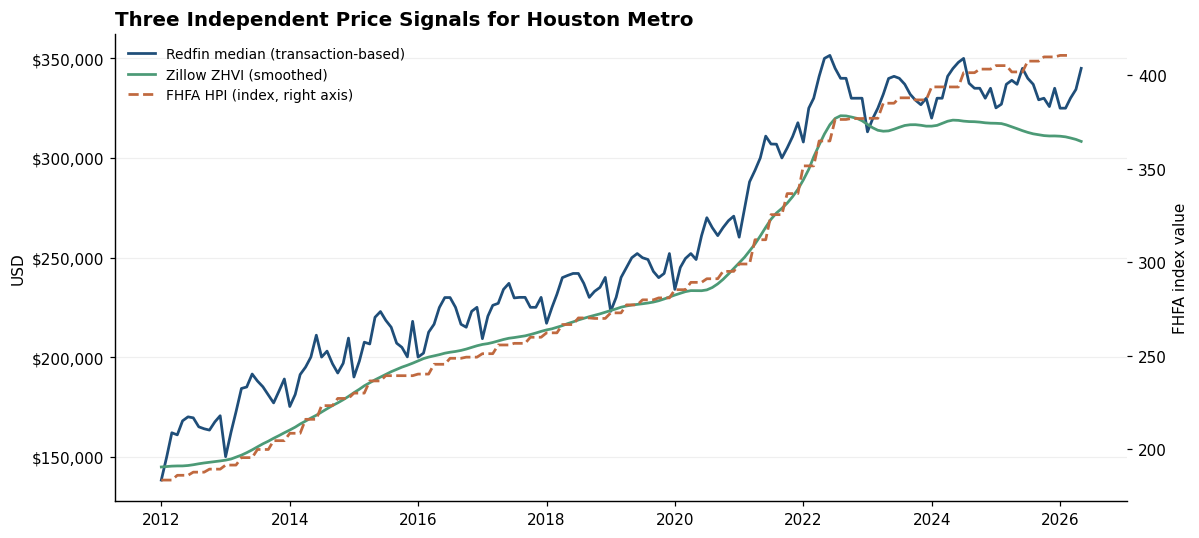

In [3]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(df["month"], df["median_price"], color=COLOR_PRIMARY, linewidth=1.8, label="Redfin median (transaction-based)")
ax1.plot(df["month"], df["zhvi_typical_home_value"], color=COLOR_ACCENT, linewidth=1.8, label="Zillow ZHVI (smoothed)")
ax1.set_ylabel("USD")
ax1.yaxis.set_major_formatter(lambda x, pos: f"${x:,.0f}")

ax2 = ax1.twinx()
ax2.plot(df["month"], df["fhfa_hpi_houston_metro"], color=COLOR_SECONDARY, linewidth=1.8, linestyle="--", label="FHFA HPI (index, right axis)")
ax2.set_ylabel("FHFA index value")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc="upper left", fontsize=9)
ax1.set_title("Three Independent Price Signals for Houston Metro", fontsize=13, fontweight="bold", loc="left")
ax1.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "09_three_price_signals.png", dpi=150)
plt.show()

In [4]:
price_corr = df[["median_price", "zhvi_typical_home_value", "fhfa_hpi_houston_metro"]].corr()
price_corr

,median_price,zhvi_typical_home_value,fhfa_hpi_houston_metro
median_price,1.000000,0.988387,0.978867
zhvi_typical_home_value,0.988387,1.000000,0.991599
fhfa_hpi_houston_metro,0.978867,0.991599,1.000000


## 3. Oil price and the Houston housing cycle

Houston's economy is unusually tied to energy. The 2015-2016 oil price collapse
is a natural test case: does the local housing market show a visible response
in this window, distinct from the national mortgage-rate environment?

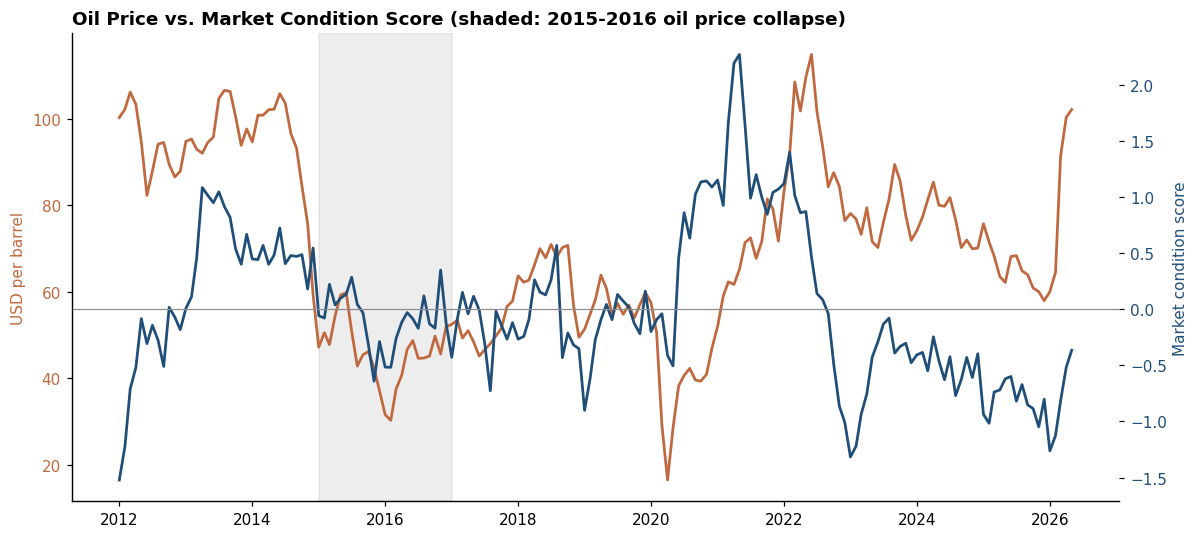

In [5]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(df["month"], df["wti_oil_price_usd_bbl"], color=COLOR_SECONDARY, linewidth=1.8, label="WTI oil price (USD/bbl)")
ax1.set_ylabel("USD per barrel", color=COLOR_SECONDARY)
ax1.tick_params(axis="y", labelcolor=COLOR_SECONDARY)
ax1.axvspan(pd.Timestamp("2015-01-01"), pd.Timestamp("2016-12-31"), color=COLOR_MUTED, alpha=0.15)

ax2 = ax1.twinx()
ax2.plot(df["month"], df["market_condition_score"], color=COLOR_PRIMARY, linewidth=1.8, label="Market condition score")
ax2.axhline(0, color=COLOR_MUTED, linewidth=0.8)
ax2.set_ylabel("Market condition score", color=COLOR_PRIMARY)
ax2.tick_params(axis="y", labelcolor=COLOR_PRIMARY)

ax1.set_title("Oil Price vs. Market Condition Score (shaded: 2015-2016 oil price collapse)", fontsize=12, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(FIG_DIR / "10_oil_price_vs_market_condition.png", dpi=150)
plt.show()

In [6]:
oil_window = df[(df["month"] >= "2014-01-01") & (df["month"] <= "2017-12-31")]
print("Average market_condition_score, 2014 (pre-collapse):", round(df[(df["month"]>="2014-01-01")&(df["month"]<"2015-01-01")]["market_condition_score"].mean(), 3))
print("Average market_condition_score, 2015-2016 (collapse):", round(df[(df["month"]>="2015-01-01")&(df["month"]<"2017-01-01")]["market_condition_score"].mean(), 3))
print("Average market_condition_score, 2017 (recovery):", round(df[(df["month"]>="2017-01-01")&(df["month"]<"2018-01-01")]["market_condition_score"].mean(), 3))

Average market_condition_score, 2014 (pre-collapse): 0.471
Average market_condition_score, 2015-2016 (collapse): -0.093
Average market_condition_score, 2017 (recovery): -0.155


## 4. Local employment vs. sales activity

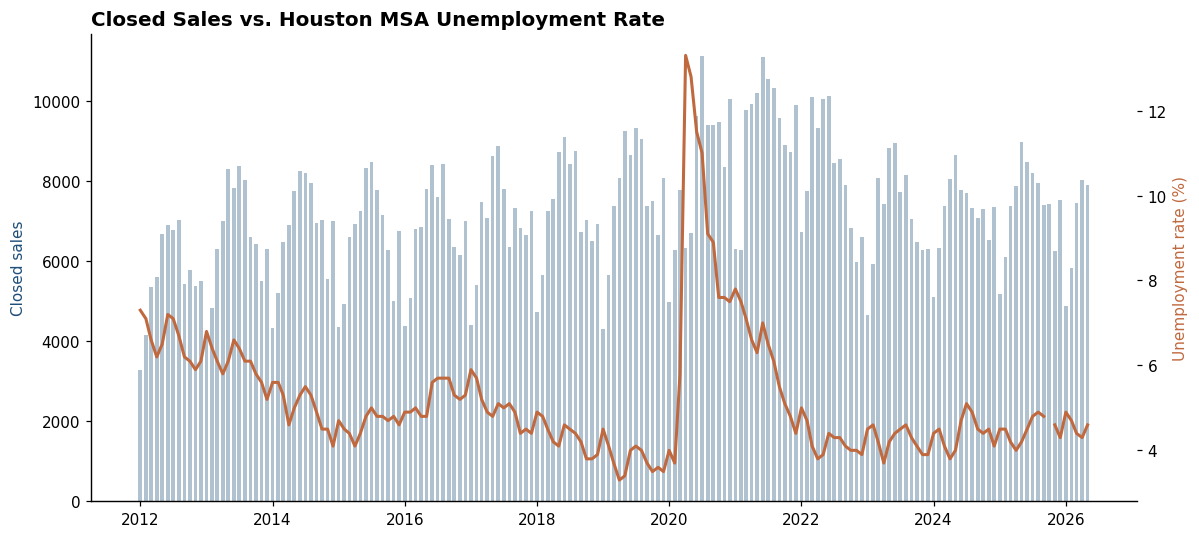

In [7]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(df["month"], df["closed_sales"], width=20, color=COLOR_PRIMARY, alpha=0.35, label="Closed sales")
ax1.set_ylabel("Closed sales", color=COLOR_PRIMARY)

ax2 = ax1.twinx()
ax2.plot(df["month"], df["houston_unemployment_rate_pct"], color=COLOR_SECONDARY, linewidth=2, label="Houston MSA unemployment rate")
ax2.set_ylabel("Unemployment rate (%)", color=COLOR_SECONDARY)

ax1.set_title("Closed Sales vs. Houston MSA Unemployment Rate", fontsize=13, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(FIG_DIR / "11_employment_vs_sales.png", dpi=150)
plt.show()

In [8]:
emp_corr = df[["closed_sales", "sales_yoy_change", "houston_unemployment_rate_pct", "employment_yoy_change"]].corr()
emp_corr

,closed_sales,sales_yoy_change,houston_unemployment_rate_pct,employment_yoy_change
closed_sales,1.000000,0.087526,0.069433,-0.061097
sales_yoy_change,0.087526,1.000000,0.289472,-0.044017
houston_unemployment_rate_pct,0.069433,0.289472,1.000000,-0.598189
employment_yoy_change,-0.061097,-0.044017,-0.598189,1.000000


## 5. Affordability with a real denominator: price-to-income and price-to-rent

`affordability_pressure_index` in v1 only measures price and rate relative to
their own history, with no income or rent denominator. These two ratios add that.

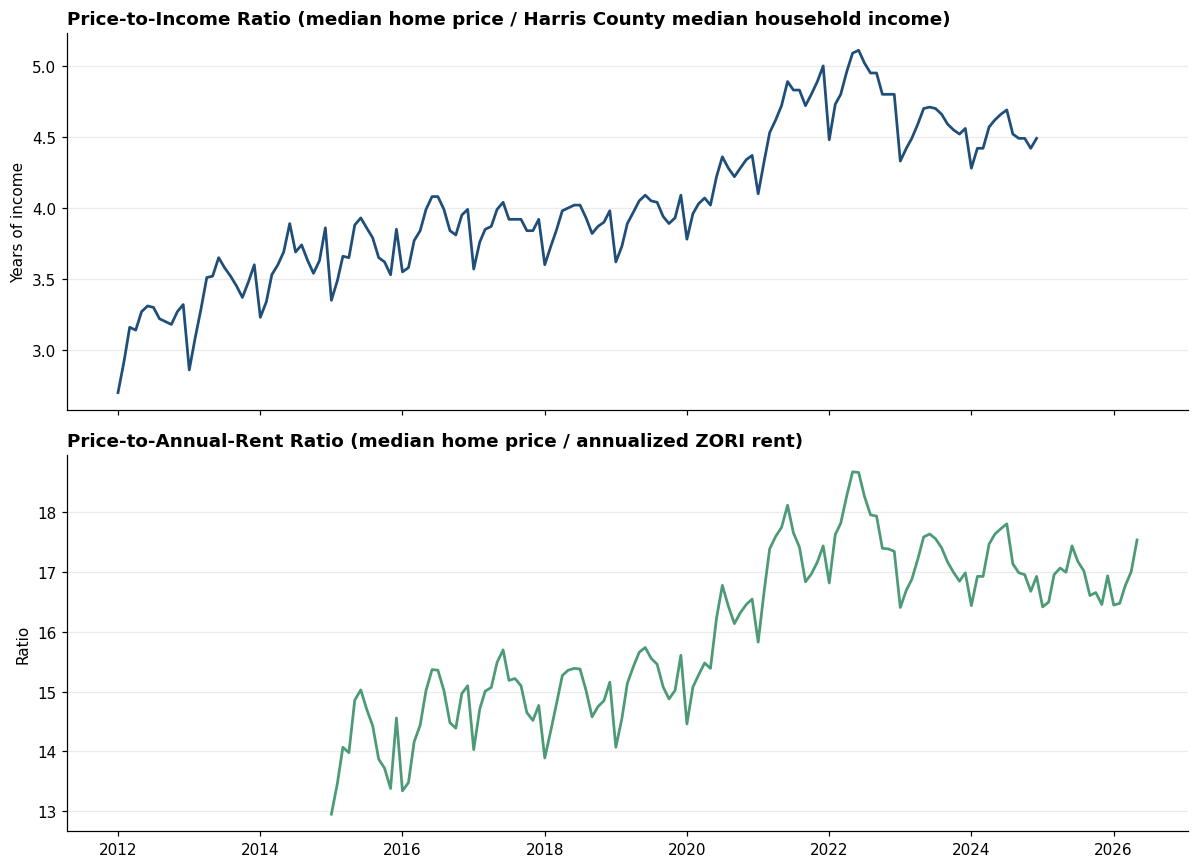

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].plot(df["month"], df["price_to_income_ratio"], color=COLOR_PRIMARY, linewidth=1.8)
axes[0].set_title("Price-to-Income Ratio (median home price / Harris County median household income)", fontsize=12, fontweight="bold", loc="left")
axes[0].set_ylabel("Years of income")
axes[0].grid(axis="y", alpha=0.25)

axes[1].plot(df["month"], df["price_to_annual_rent_ratio"], color=COLOR_ACCENT, linewidth=1.8)
axes[1].set_title("Price-to-Annual-Rent Ratio (median home price / annualized ZORI rent)", fontsize=12, fontweight="bold", loc="left")
axes[1].set_ylabel("Ratio")
axes[1].grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(FIG_DIR / "12_affordability_ratios.png", dpi=150)
plt.show()

## 6. Lead-lag: does the mortgage rate or oil price predict sales activity?

The public case study reported a same-month correlation between mortgage rate
and sales close to zero. That earlier check used raw closed_sales (a
non-stationary count with a long-run trend) against the rate level at lag zero
only. Here the comparison uses sales_yoy_change (already detrended) against
the rate and oil price levels across a range of lags, from -6 (sales leading)
to +6 (rate or oil leading).

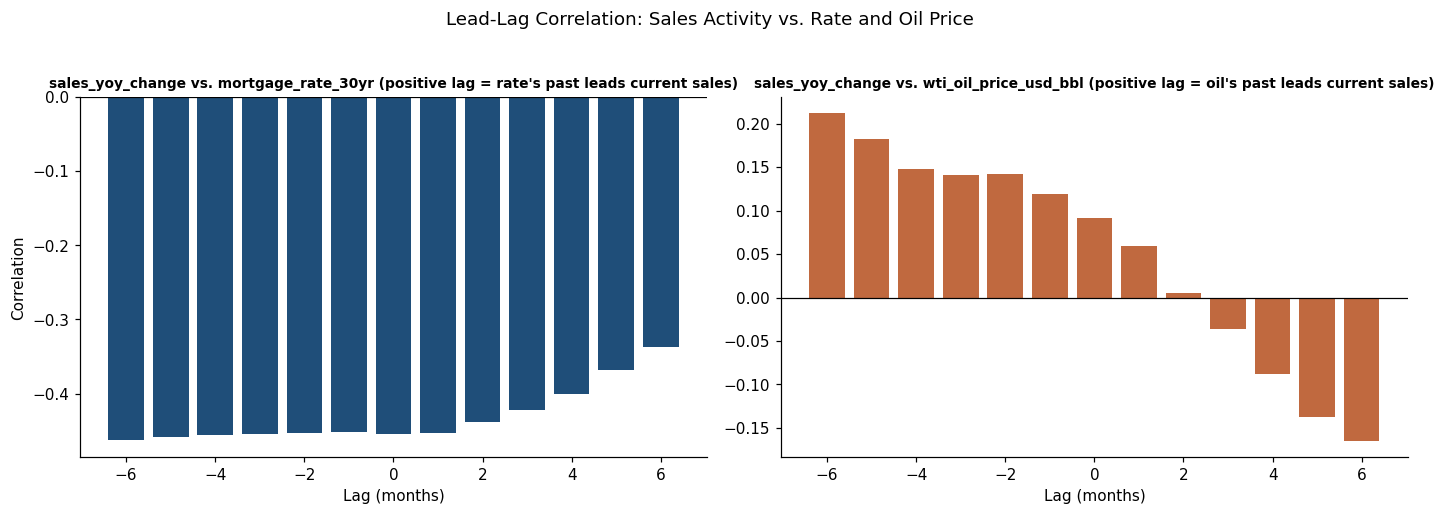

In [10]:
def lagged_corr(series_a, series_b, max_lag=6):
    # series_b.shift(lag) at time t equals series_b[t - lag], so a positive lag
    # compares current series_a to series_b's past (series_b leads series_a);
    # a negative lag compares current series_a to series_b's future (series_a
    # leads series_b).
    results = []
    for lag in range(-max_lag, max_lag + 1):
        corr = series_a.corr(series_b.shift(lag))
        results.append({"lag_months": lag, "correlation": corr})
    return pd.DataFrame(results)

rate_lag = lagged_corr(df["sales_yoy_change"], df["mortgage_rate_30yr"])
oil_lag = lagged_corr(df["sales_yoy_change"], df["wti_oil_price_usd_bbl"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(rate_lag["lag_months"], rate_lag["correlation"], color=COLOR_PRIMARY)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("sales_yoy_change vs. mortgage_rate_30yr (positive lag = rate's past leads current sales)", fontsize=9, fontweight="bold")
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Correlation")

axes[1].bar(oil_lag["lag_months"], oil_lag["correlation"], color=COLOR_SECONDARY)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("sales_yoy_change vs. wti_oil_price_usd_bbl (positive lag = oil's past leads current sales)", fontsize=9, fontweight="bold")
axes[1].set_xlabel("Lag (months)")

fig.suptitle("Lead-Lag Correlation: Sales Activity vs. Rate and Oil Price", fontsize=12, y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "13_lead_lag_correlation.png", dpi=150)
plt.show()

In [11]:
print("Strongest |correlation|, mortgage rate vs sales_yoy_change:")
print(rate_lag.loc[rate_lag["correlation"].abs().idxmax()])
print()
print("Strongest |correlation|, oil price vs sales_yoy_change:")
print(oil_lag.loc[oil_lag["correlation"].abs().idxmax()])

Strongest |correlation|, mortgage rate vs sales_yoy_change:
lag_months    -6.000000
correlation   -0.462367
Name: 0, dtype: float64

Strongest |correlation|, oil price vs sales_yoy_change:
lag_months    -6.000000
correlation    0.212199
Name: 0, dtype: float64


## 7. Seasonality: which calendar months run structurally strong or weak

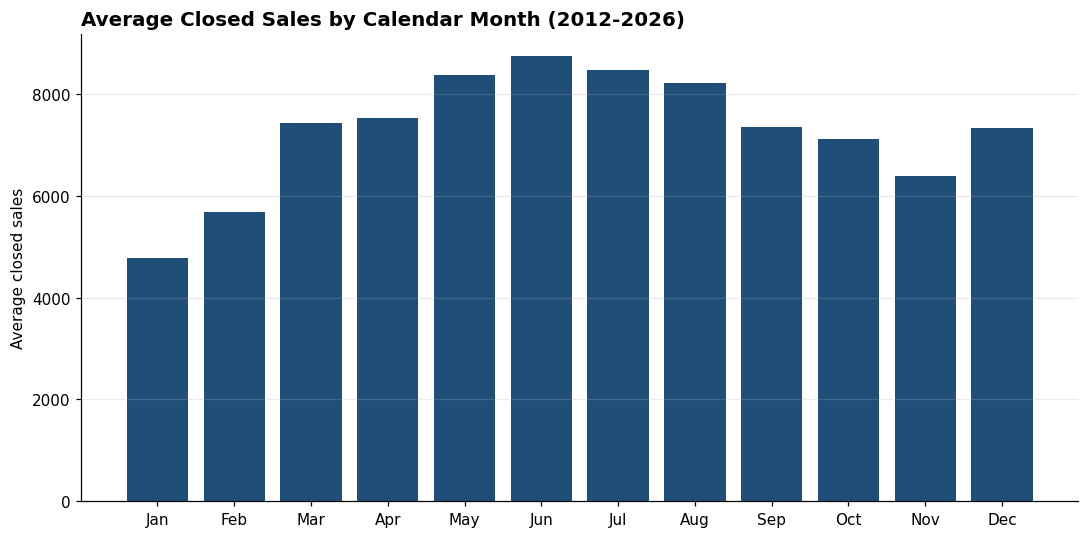

In [12]:
seasonal = df.copy()
seasonal["calendar_month"] = seasonal["month"].dt.month
seasonal_avg = seasonal.groupby("calendar_month")[["closed_sales", "sales_yoy_change"]].mean()
seasonal_avg.index = pd.to_datetime(seasonal_avg.index, format="%m").strftime("%b")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(seasonal_avg.index, seasonal_avg["closed_sales"], color=COLOR_PRIMARY)
ax.set_title("Average Closed Sales by Calendar Month (2012-2026)", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Average closed sales")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "14_seasonality_by_month.png", dpi=150)
plt.show()

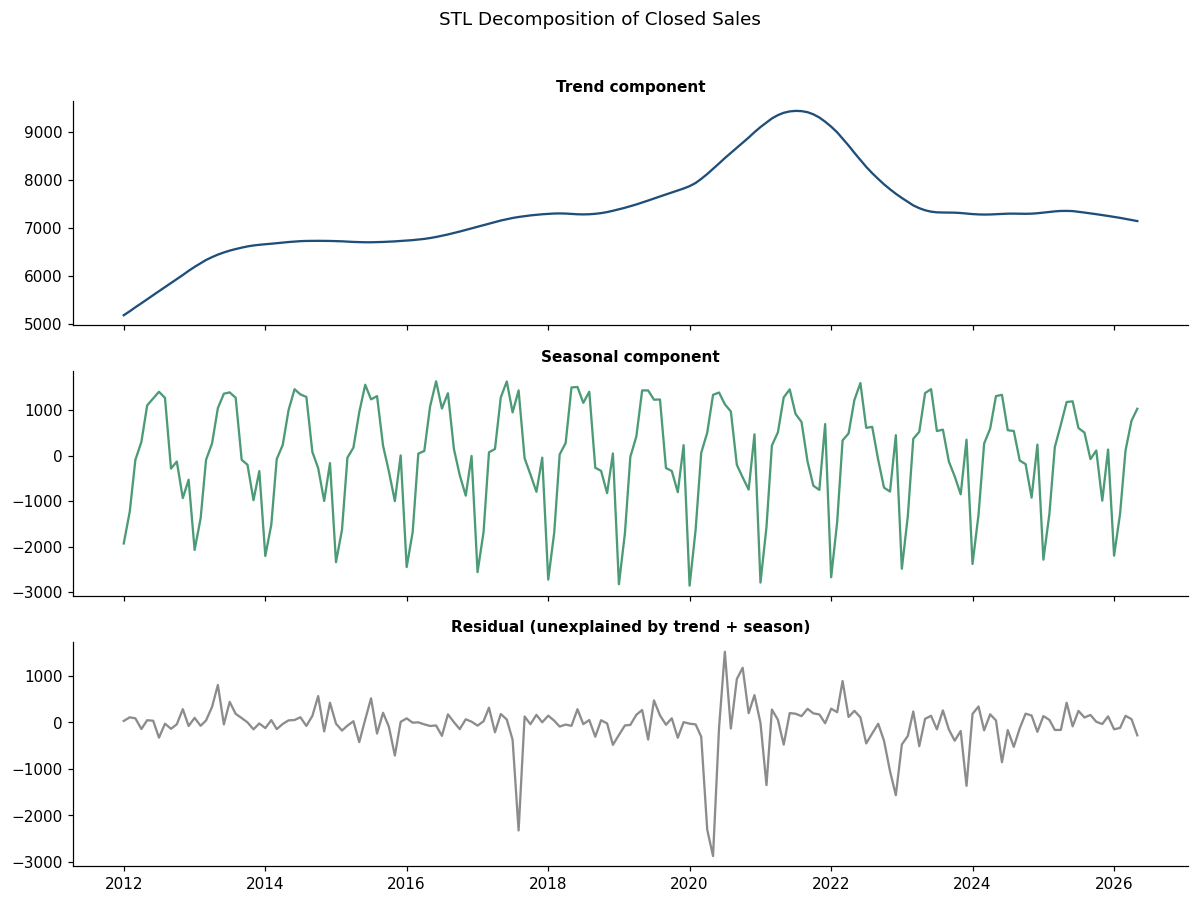

In [13]:
from statsmodels.tsa.seasonal import STL

sales_series = df.set_index("month")["closed_sales"].asfreq("MS").interpolate()
stl = STL(sales_series, period=12, robust=True).fit()

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].plot(stl.trend, color=COLOR_PRIMARY)
axes[0].set_title("Trend component", fontsize=10, fontweight="bold")
axes[1].plot(stl.seasonal, color=COLOR_ACCENT)
axes[1].set_title("Seasonal component", fontsize=10, fontweight="bold")
axes[2].plot(stl.resid, color=COLOR_MUTED)
axes[2].set_title("Residual (unexplained by trend + season)", fontsize=10, fontweight="bold")
fig.suptitle("STL Decomposition of Closed Sales", fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "15_sales_stl_decomposition.png", dpi=150)
plt.show()

## 8. Absorption rate and new-to-closed ratio: a faster-moving supply-demand read

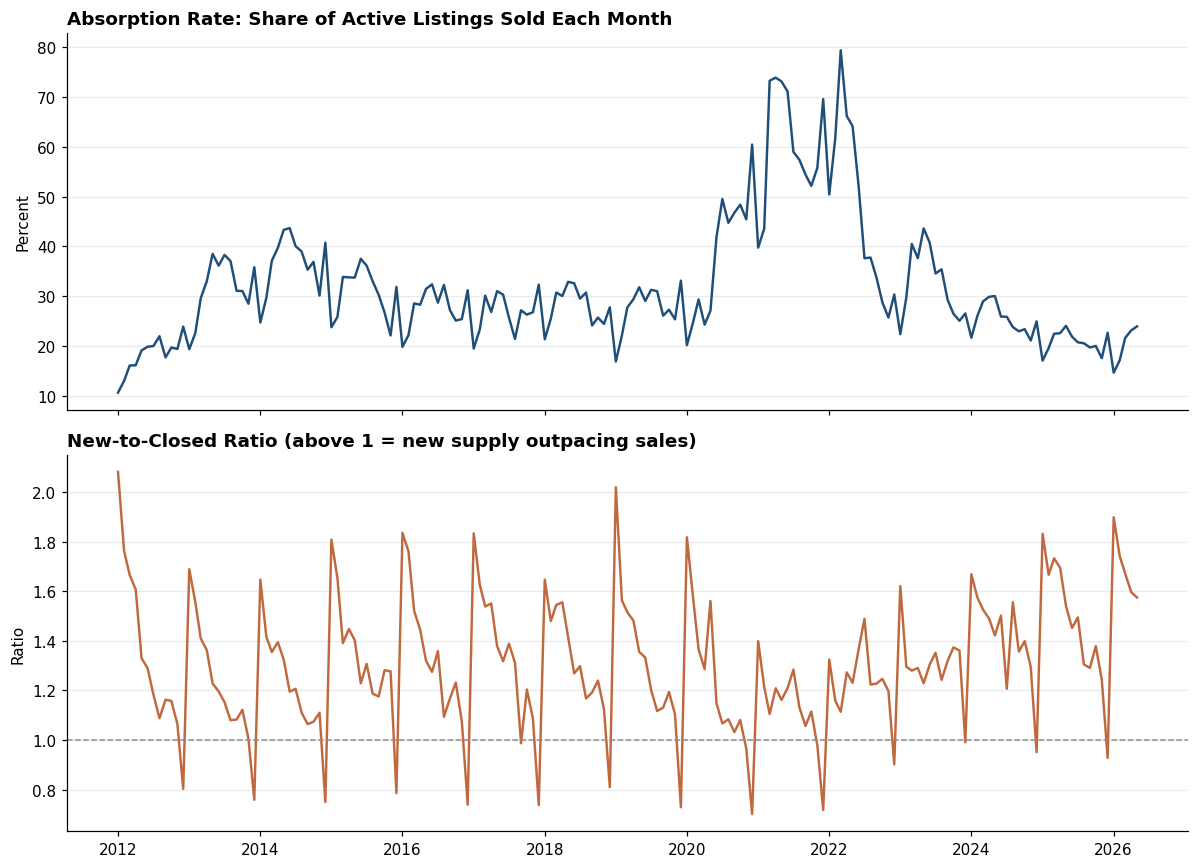

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].plot(df["month"], df["absorption_rate_pct"], color=COLOR_PRIMARY, linewidth=1.6)
axes[0].set_title("Absorption Rate: Share of Active Listings Sold Each Month", fontsize=12, fontweight="bold", loc="left")
axes[0].set_ylabel("Percent")
axes[0].grid(axis="y", alpha=0.25)

axes[1].plot(df["month"], df["new_to_closed_ratio"], color=COLOR_SECONDARY, linewidth=1.6)
axes[1].axhline(1, color=COLOR_MUTED, linewidth=1, linestyle="--")
axes[1].set_title("New-to-Closed Ratio (above 1 = new supply outpacing sales)", fontsize=12, fontweight="bold", loc="left")
axes[1].set_ylabel("Ratio")
axes[1].grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(FIG_DIR / "16_absorption_and_supply_pressure.png", dpi=150)
plt.show()

## 9. Permit mix: single-family share of new residential permits

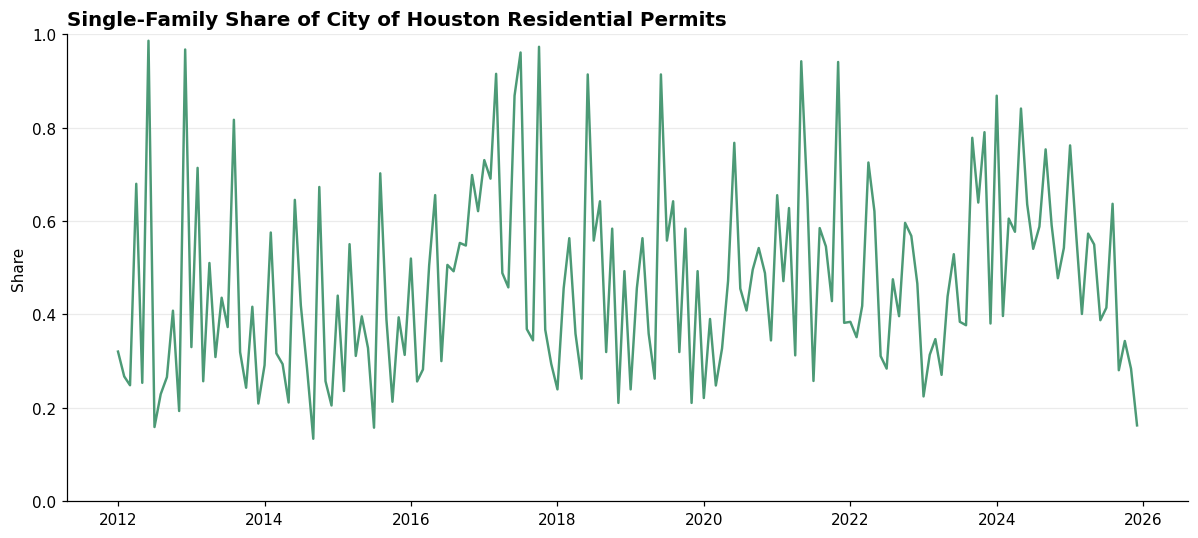

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df["month"], df["permit_single_family_share"], color=COLOR_ACCENT, linewidth=1.6)
ax.set_title("Single-Family Share of City of Houston Residential Permits", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Share")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "17_permit_single_family_share.png", dpi=150)
plt.show()

## 10. Event study: three known shocks

Comparing average market indicators in three defined windows against the 24
months immediately before each one: the 2015-2016 oil price collapse, the 2020
pandemic-era demand surge, and the 2022-2023 rate-hike cycle.

In [16]:
def window_summary(before_start, before_end, during_start, during_end, label):
    before = df[(df["month"] >= before_start) & (df["month"] < before_end)]
    during = df[(df["month"] >= during_start) & (df["month"] <= during_end)]
    return {
        "event": label,
        "before_window": f"{before_start} to {before_end}",
        "during_window": f"{during_start} to {during_end}",
        "avg_market_condition_score_before": round(before["market_condition_score"].mean(), 3),
        "avg_market_condition_score_during": round(during["market_condition_score"].mean(), 3),
        "avg_sales_yoy_change_before": round(before["sales_yoy_change"].mean(), 4),
        "avg_sales_yoy_change_during": round(during["sales_yoy_change"].mean(), 4),
        "avg_price_yoy_change_before": round(before["price_yoy_change"].mean(), 4),
        "avg_price_yoy_change_during": round(during["price_yoy_change"].mean(), 4),
    }

events = pd.DataFrame([
    window_summary("2013-01-01", "2015-01-01", "2015-01-01", "2016-12-31", "2015-2016 oil price collapse"),
    window_summary("2018-03-01", "2020-03-01", "2020-03-01", "2021-12-31", "2020-2021 pandemic-era surge"),
    window_summary("2020-03-01", "2022-03-01", "2022-03-01", "2023-12-31", "2022-2023 rate-hike cycle"),
])
events

,event,before_window,during_window,avg_market_condition_score_before,avg_market_condition_score_during,avg_sales_yoy_change_before,avg_sales_yoy_change_during,avg_price_yoy_change_before,avg_price_yoy_change_during
0,2015-2016 oil price collapse,2013-01-01 to 2015-01-01,2015-01-01 to 2016-12-31,0.570,-0.093,0.1028,0.0041,0.0989,0.0560
1,2020-2021 pandemic-era surge,2018-03-01 to 2020-03-01,2020-03-01 to 2021-12-31,-0.091,0.973,0.0494,0.1249,0.0370,0.1129
2,2022-2023 rate-hike cycle,2020-03-01 to 2022-03-01,2022-03-01 to 2023-12-31,0.997,-0.254,0.1271,-0.1375,0.1188,0.0451


## 11. Regime clustering: does an unsupervised grouping agree with `market_condition_label`?

`market_condition_label` uses fixed thresholds (+/-0.5) on `market_condition_score`.
K-means with 3 clusters, fit on the same five standardized inputs, is a data-driven
check on whether that fixed-threshold labeling holds up against a method that
doesn't assume where the boundaries should be.

In [17]:
features = ["price_yoy_change", "sales_yoy_change", "months_inventory", "days_on_market", "inventory_yoy_change"]
cluster_df = df.dropna(subset=features).copy()

X = StandardScaler().fit_transform(cluster_df[features])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X)

# Label clusters by their mean market_condition_score so the comparison reads naturally
cluster_order = cluster_df.groupby("cluster")["market_condition_score"].mean().sort_values().index
cluster_name_map = {cluster_order[0]: "cluster: cooler-leaning", cluster_order[1]: "cluster: balanced-leaning", cluster_order[2]: "cluster: warmer-leaning"}
cluster_df["cluster_name"] = cluster_df["cluster"].map(cluster_name_map)

pd.crosstab(cluster_df["cluster_name"], cluster_df["market_condition_label"])

market_condition_label,balanced,cooler,warmer
cluster_name,,,
cluster: balanced-leaning,76,32,0
cluster: cooler-leaning,10,7,0
cluster: warmer-leaning,13,0,35


In [18]:
agreement = (
    (cluster_df["cluster_name"] == "cluster: cooler-leaning") & (cluster_df["market_condition_label"] == "cooler")
    | (cluster_df["cluster_name"] == "cluster: balanced-leaning") & (cluster_df["market_condition_label"] == "balanced")
    | (cluster_df["cluster_name"] == "cluster: warmer-leaning") & (cluster_df["market_condition_label"] == "warmer")
).mean()
print(f"Share of months where the k-means cluster and the fixed-threshold label point the same direction: {agreement:.1%}")

Share of months where the k-means cluster and the fixed-threshold label point the same direction: 68.2%


## 12. Real (inflation-adjusted) prices and rent

Nominal median price has risen across most of this dataset's history, but
some of that increase is just inflation, not homes becoming more expensive
in real terms. `real_median_price` and `real_zori_rent_index` deflate the
nominal series to constant dollars of the most recent month using CPI-U
(FRED `CPIAUCSL`), so the two lines below can be compared on an
apples-to-apples basis.

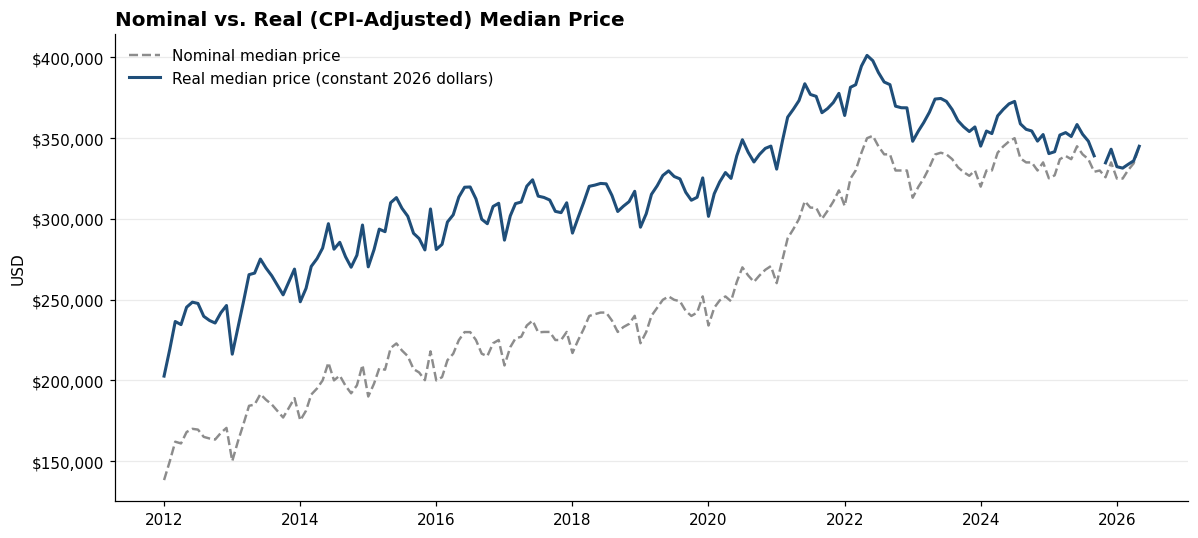

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df["month"], df["median_price"], color=COLOR_MUTED, linewidth=1.6, linestyle="--", label="Nominal median price")
ax.plot(df["month"], df["real_median_price"], color=COLOR_PRIMARY, linewidth=2, label=f"Real median price (constant {df['month'].max().year} dollars)")
ax.set_title("Nominal vs. Real (CPI-Adjusted) Median Price", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(lambda x, pos: f"${x:,.0f}")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "18_real_vs_nominal_price.png", dpi=150)
plt.show()

In [20]:
nominal_growth = df["median_price"].iloc[-1] / df["median_price"].iloc[0] - 1
real_growth = df["real_median_price"].iloc[-1] / df["real_median_price"].iloc[0] - 1
print(f"Nominal median price change, {df['month'].iloc[0].date()} to {df['month'].iloc[-1].date()}: {nominal_growth:.1%}")
print(f"Real (CPI-adjusted) median price change, same period: {real_growth:.1%}")
print(f"Share of nominal growth attributable to inflation: {(nominal_growth - real_growth) / nominal_growth:.1%}")

Nominal median price change, 2012-01-01 to 2026-05-01: 149.5%
Real (CPI-adjusted) median price change, same period: 70.2%
Share of nominal growth attributable to inflation: 53.0%


## 13. Formal causality testing (R)

The lead-lag correlation scan in section 6 found a fairly flat relationship
across the tested window, without a clear peak, which isn't conclusive on
its own. `methodology/r_analysis/granger_causality.R` formalizes this with
Granger causality tests (R's `lmtest` and `tseries` packages), asking a
sharper question: do past values of the mortgage rate, oil price, or local
employment growth improve a forecast of `sales_yoy_change` beyond what its
own history already provides?

R is used for this one piece because `lmtest::grangertest` and
`tseries::adf.test` are the standard, well-tested tools for this specific
class of test, with cleaner output than the closest Python equivalent. See
`methodology/r_analysis/README.md` for the full write-up; the headline
results are loaded below.

In [21]:
granger_results = pd.read_csv("../methodology/r_analysis/granger_causality_results_differenced.csv")
granger_results

,predictor,target,lag_months,f_statistic,p_value,significant_at_5pct
0,mortgage_rate_30yr (first diff),sales_yoy_change (first diff),3,1.246,0.2951,False
1,mortgage_rate_30yr (first diff),sales_yoy_change (first diff),6,1.035,0.4047,False
2,mortgage_rate_30yr (first diff),sales_yoy_change (first diff),12,0.818,0.6315,False
3,oil_price_yoy_change (first diff),sales_yoy_change (first diff),3,10.084,0.0000,True
4,oil_price_yoy_change (first diff),sales_yoy_change (first diff),6,6.213,0.0000,True
5,oil_price_yoy_change (first diff),sales_yoy_change (first diff),12,3.835,0.0001,True
6,employment_yoy_change (first diff),sales_yoy_change (first diff),3,18.747,0.0000,True
7,employment_yoy_change (first diff),sales_yoy_change (first diff),6,9.938,0.0000,True
8,employment_yoy_change (first diff),sales_yoy_change (first diff),12,5.480,0.0000,True


None of the four series (`sales_yoy_change`, `mortgage_rate_30yr`,
`oil_price_yoy_change`, `employment_yoy_change`) passed a stationarity test
in their original form, so the table above uses first-differenced,
stationarity-confirmed versions of each series (see the R script's ADF
output for detail). After that correction: oil price and employment growth
both Granger-cause `sales_yoy_change` at every lag tested (p < 0.001 in all
cases), while the mortgage rate does not, at any lag. This is a sharper,
statistically formal version of the same conclusion the correlation scan in
section 6 could only gesture at: the rate has a real but non-predictive
association with sales growth, while oil and employment carry genuine
predictive information about it in this dataset.

Granger causality tests predictive information content in a time series,
not a real-world causal mechanism. A significant result here does not by
itself prove oil prices or employment are the true cause of sales
movements, rule out a shared third factor, or license a forecast beyond
this dataset's own window.

## 14. Findings summary

- Three independent price signals largely agree. Redfin's median, Zillow's
  ZHVI, and the FHFA HPI move together over the full period (see the
  correlation table in section 2), which is reassuring: the price trends in
  this project aren't an artifact of any single provider's methodology.
- The 2015-2016 oil price collapse shows up clearly in the local market
  condition score. Average market_condition_score drops from the 2014
  pre-collapse level through 2015-2016 and only partially recovers in 2017,
  consistent with Houston's energy-linked economy and with the event-study
  table in section 10. The two series visibly track each other through most
  of the chart in section 3, not just in this one window.
- Employment correlates with sales activity more clearly than the same-month
  mortgage rate did in the original case study. The unemployment-rate and
  payroll-growth correlations with sales in section 4 are more informative
  than the near-zero same-month mortgage-rate correlation reported there,
  though this remains a correlation, not a causal claim.
- The rate-sales relationship is stronger than the original same-month check
  suggested, but it isn't a sharp lead-lag effect. Once sales are measured as
  year-over-year growth (detrended) instead of a raw count, the correlation
  with the mortgage rate is consistently around -0.45 across nearly the whole
  tested window (-6 to +6 months), gradually weakening only toward the
  positive-lag edge. That flatness, rather than a distinct peak, suggests a
  persistent regime-level association between higher rates and slower sales
  growth, not a specific number of months of delay. The oil-price correlation
  shows a similar pattern in the opposite direction: strongest at the
  most-negative lag tested and weakening steadily toward positive lags, which
  points at broad multi-year co-movement between oil and sales cycles more
  than a short-horizon leading indicator. Both patterns are cleaner questions
  for a dedicated time-series model than for a simple lagged-correlation scan.
- Seasonality is real and worth removing before reading short-term trend
  changes as market signal. The STL decomposition in section 7 separates a
  clear repeating seasonal pattern from the underlying trend; a few months of
  softening sales can be entirely seasonal rather than a market shift.
- The STL residual flags a sharp, one-month dip in August 2017 that isn't
  explained by trend or seasonality. Closed sales fell 24.6% year-over-year
  that month before immediately recovering in September, which lines up with
  Hurricane Harvey, not a broader market shift. This is exactly the kind of
  event a residual-based check is useful for: separating a real but temporary
  local shock from a change in the underlying trend.
- Price-to-income and price-to-rent add a denominator the original
  affordability index didn't have. Both ratios in section 5 give an absolute
  affordability read (years of income, or multiples of annual rent),
  complementing rather than replacing the history-relative
  affordability_pressure_index from v1.
- The fixed-threshold market condition label mostly agrees with a data-driven
  clustering, per section 11's agreement rate, which is a reasonable
  validation of the simple approach used in v1 without requiring the added
  complexity of a clustering model for everyday use.
- About half of the nominal price increase in this dataset is inflation, not
  real appreciation. Nominal median price rose 149.5% from January 2012 to
  May 2026; in constant dollars, the real increase was 70.2%, meaning
  inflation accounts for roughly 53% of the nominal figure (section 12).
  Headline nominal price-growth numbers overstate how much more expensive
  homes actually became relative to everything else.
- A formal Granger causality test (R, section 13) confirms and sharpens the
  correlation-based read from section 6: oil price and employment growth both
  have statistically significant predictive power for sales growth at every
  lag tested (p < 0.001), even after correcting for non-stationarity, while
  the mortgage rate does not, at any lag. This is stronger evidence than a
  correlation scan alone that oil and local jobs carry real predictive
  information about Houston sales activity, while the rate's relationship
  looks more like a persistent association than a specific lead-lag effect.

## 15. Limitations

- No causal claims anywhere in this notebook. Every relationship shown (oil
  vs. market condition, employment vs. sales, rate and oil lags) is a
  correlational or descriptive observation.
- The lead-lag scan in section 6 is limited to a 6-month window in each
  direction. Both series show their strongest correlation at the edge of that
  window rather than a clear interior peak, which means the true relationship
  (if it has a specific lead time at all) may extend beyond what was tested
  here, or may simply reflect multi-year cycles that a short lag window
  cannot cleanly separate from a persistent regime-level association.
- Mixed source frequency: FHFA HPI (quarterly) and Harris County income
  (annual) are flat-filled to monthly, which can understate real
  within-quarter or within-year movement.
- Harris County income is a narrower geography than the Houston metro used by
  every other source in this analysis.
- The k-means clustering in section 11 is a validation check, not a
  replacement for the documented, transparent market_condition_score formula;
  it uses a fixed random seed and is not re-optimized for business
  interpretability the way the manual thresholds were.
- STL decomposition assumes a fixed 12-month seasonal period and is sensitive
  to the interpolation used for any source gaps in closed_sales (there are
  none in this dataset, but this would matter if new gaps appear after future
  data refreshes).
- Real price and rent (section 12) are deflated using national CPI-U, not a
  Houston-specific cost-of-living index, since no public Houston-metro CPI
  series was identified during this research pass. Local inflation may differ
  from the national rate used here.
- Granger causality (section 13, R) tests predictive information content in a
  time series sense, not a real-world causal mechanism. A significant result
  does not prove oil prices or employment are the true cause of sales
  movements, rule out a shared third factor, or license a forecast beyond
  this dataset's own window. Results are also sensitive to the differencing
  and lag order chosen; see methodology/r_analysis/README.md for the full
  stationarity discussion.
- Full source and geography limitations: data/data_dictionary_extended.md and
  data/source_notes.md.